In [ ]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',1000)
import itertools
import warnings
warnings.filterwarnings("ignore")
import io
from plotly.offline import init_notebook_mode, plot,iplot
import plotly.graph_objs as go
init_notebook_mode(connected=True)
import matplotlib.pyplot as plt
import plotly.tools as tls
import plotly.figure_factory as ff
import seaborn as sns
from sklearn.cluster import KMeans , MeanShift
from sklearn import decomposition
from sklearn.preprocessing import MultiLabelBinarizer

In [27]:
df=pd.read_csv('./players.csv')
df.head(5)

,Unnamed: 0.1,Unnamed: 0,Rank,Name,OVR,PAC,SHO,PAS,DRI,DEF,PHY,Acceleration,Sprint Speed,Positioning,Finishing,Shot Power,Long Shots,Volleys,Penalties,Vision,Crossing,Free Kick Accuracy,Short Passing,Long Passing,Curve,Dribbling,Agility,Balance,Reactions,Ball Control,Composure,Interceptions,Heading Accuracy,Def Awareness,Standing Tackle,Sliding Tackle,Jumping,Stamina,Strength,Aggression,Position,Weak foot,Skill moves,Preferred foot,Height,Weight,Alternative positions,Age,Nation,League,Team,play style,url,GK Diving,GK Handling,GK Kicking,GK Positioning,GK Reflexes
0,0,0,1,Kylian Mbappé,91,97,90,80,92,36,78,97,97,93,94,90,83,84,84,83,78,69,86,71,80,93,93,82,93,92,88,38,73,26,34,32,88,88,77,64,ST,4,5,Right,"182cm / 6'0""",75kg / 165lb,LW,25,France,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Acrobatic, Finesse Shot, Flair, R...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
1,1,1,2,Rodri,91,66,80,86,84,87,85,65,66,76,74,92,89,71,62,84,76,64,93,91,86,84,66,67,93,90,94,84,81,92,87,82,83,91,83,85,CDM,4,3,Right,"191cm / 6'3""",82kg / 181lb,CM,28,Spain,Premier League,Manchester City,"Tiki Taka+, Aerial, Bruiser, Long Ball Pass, P...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
2,2,2,4,Erling Haaland,91,88,92,70,81,45,88,80,94,96,96,94,83,90,90,74,58,62,77,66,77,79,77,69,94,83,87,43,83,38,47,29,92,76,93,88,ST,3,3,Left,"195cm / 6'5""",94kg / 207lb,NaN,24,Norway,Premier League,Manchester City,"Acrobatic+, Bruiser, Power Header, Power Shot,...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
3,3,3,5,Jude Bellingham,90,80,87,83,88,78,83,81,80,91,90,85,86,77,74,90,66,68,89,89,73,89,82,79,91,89,87,82,75,77,79,77,84,93,77,85,CAM,4,4,Right,"186cm / 6'1""",75kg / 165lb,CM,21,England,LALIGA EA SPORTS,Real Madrid,"Relentless+, Flair, Intercept, Slide Tackle, T...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN
4,4,4,7,Vini Jr.,90,95,84,81,91,29,69,95,95,87,89,81,83,73,71,85,81,62,83,77,79,93,94,84,86,90,83,26,50,32,25,18,74,84,65,58,LW,4,5,Right,"176cm / 5'9""",73kg / 161lb,"ST, LM",24,Brazil,LALIGA EA SPORTS,Real Madrid,"Quick Step+, Chip Shot, Finesse Shot, First To...",https://www.ea.com/games/ea-sports-fc/ratings/...,NaN,NaN,NaN,NaN,NaN


In [28]:
print(f"Shape del dataset: {df.shape}\n")

print(f"Variables: {df.columns}")

Shape del dataset: (16161, 58)

Variables: Index(['Unnamed: 0.1', 'Unnamed: 0', 'Rank', 'Name', 'OVR', 'PAC', 'SHO',
       'PAS', 'DRI', 'DEF', 'PHY', 'Acceleration', 'Sprint Speed',
       'Positioning', 'Finishing', 'Shot Power', 'Long Shots', 'Volleys',
       'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
       'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility',
       'Balance', 'Reactions', 'Ball Control', 'Composure', 'Interceptions',
       'Heading Accuracy', 'Def Awareness', 'Standing Tackle',
       'Sliding Tackle', 'Jumping', 'Stamina', 'Strength', 'Aggression',
       'Position', 'Weak foot', 'Skill moves', 'Preferred foot', 'Height',
       'Weight', 'Alternative positions', 'Age', 'Nation', 'League', 'Team',
       'play style', 'url', 'GK Diving', 'GK Handling', 'GK Kicking',
       'GK Positioning', 'GK Reflexes'],
      dtype='object')


In [29]:
missing = df.isnull().sum()
print(missing[missing > 0])

print("\n")

print(df.duplicated().sum())

print("\n")

print(df.describe())

Alternative positions     7247
play style                8682
GK Diving                14345
GK Handling              14345
GK Kicking               14345
GK Positioning           14345
GK Reflexes              14345
dtype: int64


0


       Unnamed: 0.1    Unnamed: 0          Rank           OVR           PAC  \
count  16161.000000  16161.000000  16161.000000  16161.000000  16161.000000   
mean    8080.000000   8080.000000   8934.139657     66.172390     68.149558   
std     4665.423186   4665.423186   5003.925857      6.761979     10.612153   
min        0.000000      0.000000      1.000000     47.000000     29.000000   
25%     4040.000000   4040.000000   5037.000000     62.000000     62.000000   
50%     8080.000000   8080.000000   9009.000000     66.000000     69.000000   
75%    12120.000000  12120.000000  13135.000000     70.000000     75.000000   
max    16160.000000  16160.000000  17717.000000     91.000000     97.000000   

                SHO           PAS           DRI     

## Definición de las variables

### Metadatos / índices

- **Unnamed: 0.1 / Unnamed: 0**: índices automáticos creados al exportar el dataset 🗑️
- **Rank**: Ranking o posición en la lista. 🗑️
- **Name**: Nombre del jugador. 
- **url**: Link al perfil del jugador en la fuente original. 🗑️

### Atributos generales

- **OVR**: Overall rating (valoración global del jugador). 
- **PAC**: Pace (ritmo: velocidad y aceleración).
- **SHO**: Shooting (tiro).
- **PAS**: Passing (pases).
- **DRI**: Dribbling (regate).
- **DEF**: Defense (defensa).
- **PHY**: Physical (físico).

### Velocidad

- **Acceleration**: Aceleración.
- **Sprint Speed**: Velocidad máxima.

### Tiro

- **Positioning**: Posicionamiento ofensivo.
- **Finishing**: Definición.
- **Shot Power**: Potencia de tiro.
- **Long Shots**: Tiros lejanos.
- **Volleys**: Voleas.
- **Penalties**: Penales.

### Pases

- **Vision**: Visión de juego.
- **Crossing**: Centros.
- **Free Kick Accuracy**: Precisión de tiros libres.
- **Short Passing**: Pase corto.
- **Long Passing**: Pase largo.
- **Curve**: Efecto.

### Regate

- **Dribbling**: Habilidad de driblar.
- **Agility**: Agilidad.
- **Balance**: Balance.
- **Reactions**: Reacciones.
- **Ball Control**: Control de balón.
- **Composure**: Compostura (mantener la calma bajo presión).

### Defensa 

- **Interceptions**: Intercepciones.
- **Heading Accuracy**: Precisión de cabezazo.
- **Def Awareness**: Colocación defensiva.
- **Standing Tackle**: Entrada de pie.
- **Sliding Tackle**: Entrada al suelo.

### Físico 

- **Jumping**: Salto.
- **Stamina**: Resistencia.
- **Strength**: Fuerza.
- **Aggression**: Agresividad.

### Información personal 

- **Position**: Posición principal (ej: ST, CAM, RB).
- **Alternative positions**: Posiciones alternativas.
- **Weak foot**: Puntuación del pie malo (1–5). 🗑️
- **Skill moves**: Número de estrellas de skills (1–5). 🗑️
- **Preferred foot**: Pie preferido (left/right). 🗑️
- **Height**: Altura. 🗑️
- **Weight**: Peso. 🗑️
- **Age**: Edad. 🗑️
- **Nation**: Nacionalidad. 🗑️ 
- **League**: Liga en la que juega. 🗑️
- **Team**: Equipo actual. 🗑️
- **Play style**: Estilo de juego (solo la mitad de los jugadores tiene esta información). 🗑️

### Estadísticas de arquero 

- **GK Diving**: Estirada.
- **GK Handling**: Blocaje.
- **GK Kicking**: Saque con el pie.
- **GK Positioning**: Posicionamiento.
- **GK Reflexes**: Reflejos.

***

## Criterios a definir y suposiciones

1. Para que un jugador sea reemplazable por otro debería estar en la misma posición o en una posición alternativa (`Alternative positions`).
2. No todos los jugadores con la misma posición son buenos reemplazos, ya que pueden variar en habilidades, estadísticas y formas de jugar.

In [30]:
# Elimino las columnas que no parecen relevantes
players = df.drop(columns=["Unnamed: 0.1", "Unnamed: 0", "Rank", "url", "Weak foot", "Skill moves", "Preferred foot", "Height", "Weight", "Age", "Nation", "League", "play style"])
# Pongo "" si la Position es nan
players["Position"] = players["Position"].fillna("")
players["Alternative positions"] = players["Alternative positions"].fillna("")
players["Alternative positions"] = players["Alternative positions"].apply(lambda x: [pos.strip() for pos in x.split(",") if pos != ""])
# Eliminar NaN de GK
players[["GK Reflexes", "GK Diving", "GK Handling", "GK Kicking", "GK Positioning"]] = players[["GK Reflexes", "GK Diving", "GK Handling", "GK Kicking", "GK Positioning"]].fillna(0)


<Axes: >

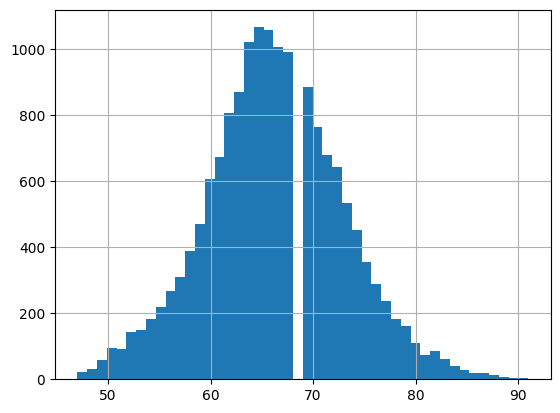

In [31]:
# Mejor jugador por posición

players['OVR'].hist(bins = 46)

In [32]:
best_players_position = players.loc[players.groupby('Position')['OVR'].idxmax(), ['Position', 'Name', 'OVR']]
best_players_position

pd.DataFrame(players.Position.value_counts().sort_index())

,count
Position,
CAM,961
CB,2924
CDM,1330
CM,1890
GK,1816
LB,1214
LM,968
LW,341
RB,1281


In [33]:
avg_ovr = players.groupby('Team')['OVR'].mean().reset_index().sort_values("OVR", ascending=False)
avg_ovr.head(10)

,Team,OVR
481,Real Madrid,81.480000
365,Lombardia FC,79.629630
204,FC Bayern München,79.444444
373,Manchester City,79.392857
359,Leverkusen,78.916667
62,Atlético de Madrid,78.851852
381,Milano FC,78.653846
432,Paris SG,78.333333
325,Juventus,78.250000
462,RB Leipzig,78.000000


In [34]:
n=10000 #cantidad de jugadores a considerar

df_n=players.loc[:n] #se reduce la base a los n primeros jugadores

df_n=df_n[(df_n['OVR']>70)]

skills = [
    'PAC', 'SHO', 'PAS', 'DRI', 'DEF', 'PHY',
    'Acceleration', 'Sprint Speed', 'Positioning', 'Finishing', 'Shot Power',
    'Long Shots', 'Volleys', 'Penalties', 'Vision', 'Crossing', 'Free Kick Accuracy',
    'Short Passing', 'Long Passing', 'Curve', 'Dribbling', 'Agility', 'Balance',
    'Reactions', 'Ball Control', 'Composure', 'Interceptions', 'Heading Accuracy',
    'Def Awareness', 'Standing Tackle', 'Sliding Tackle', 'Jumping', 'Stamina',
    'Strength', 'Aggression', 'GK Diving', 'GK Handling', 'GK Kicking', 'GK Positioning',
    'GK Reflexes'
]
print(len(skills), 'variables numéricas de desempeño según habilidad')

40 variables numéricas de desempeño según habilidad


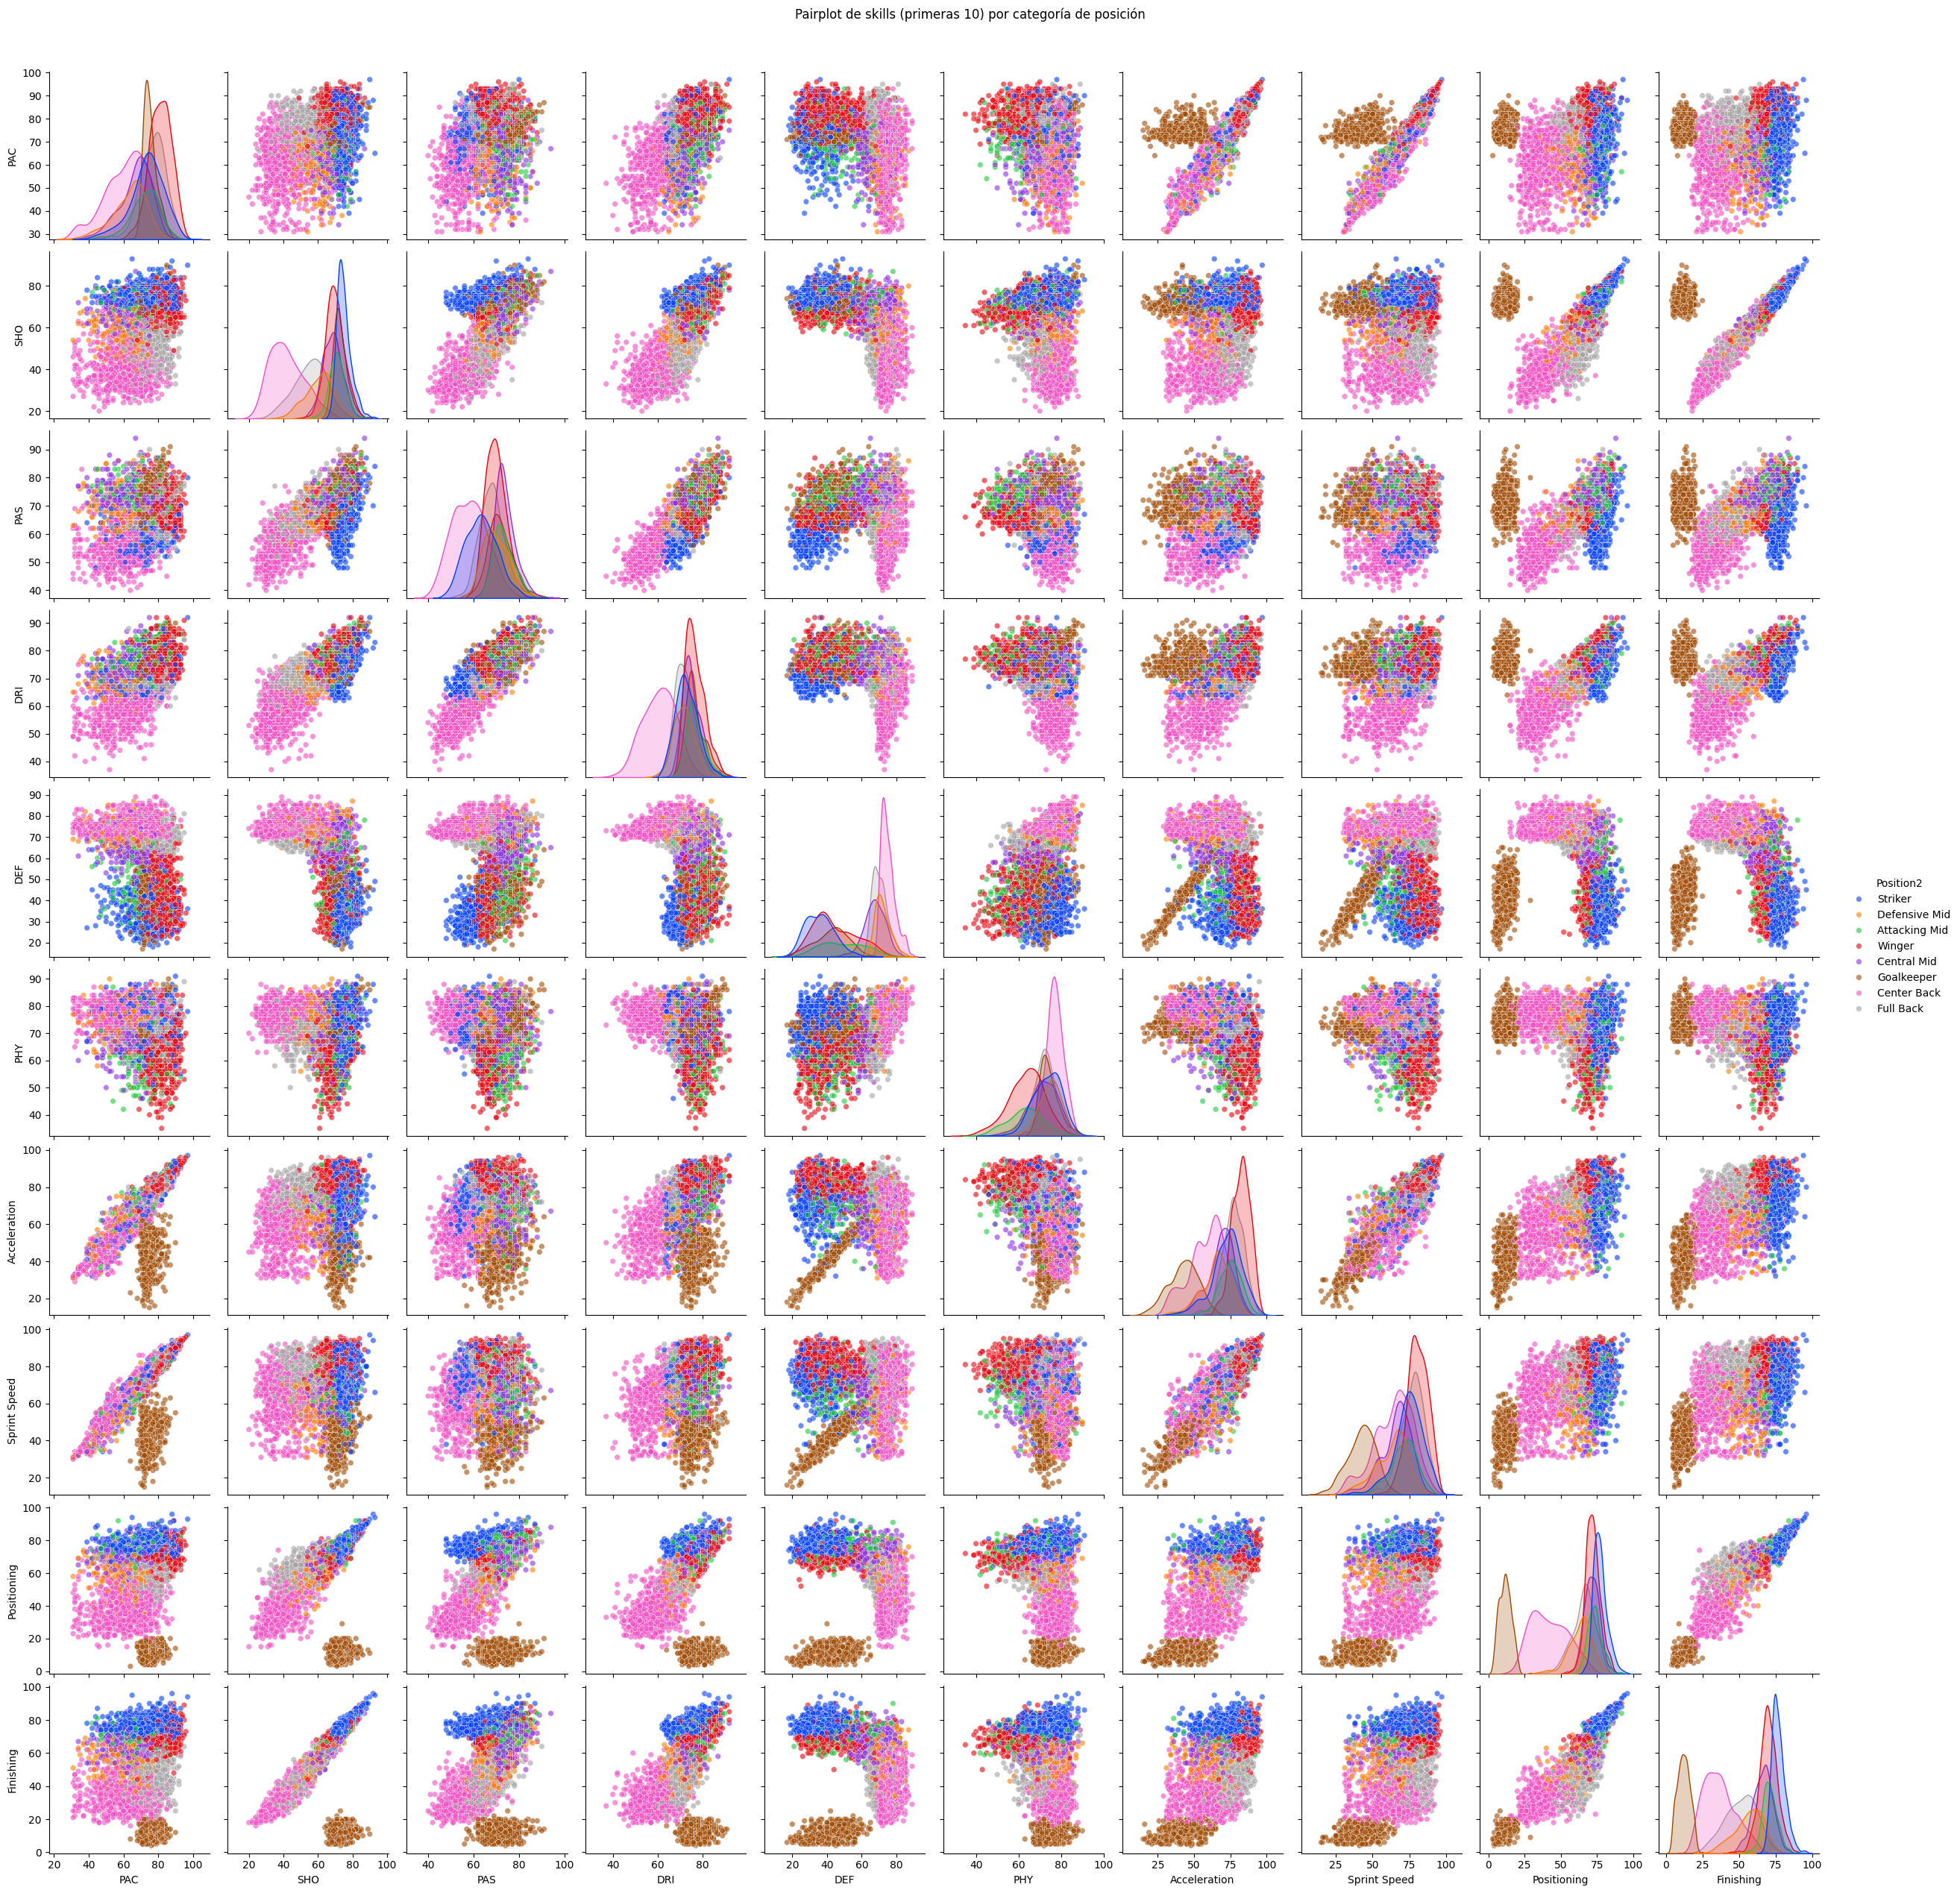

In [35]:
from sklearn.preprocessing import MultiLabelBinarizer

strikers = ['ST', 'CF', 'LS', 'RS']
wingers = ['LW', 'RW', 'LF', 'RF', 'LM', 'RM'] 
central_mid = ['CM', 'LCM', 'RCM']
attacking_mid = ['CAM', 'LAM', 'RAM']
defensive_mid = ['CDM', 'LDM', 'RDM']
center_backs = ['CB', 'RCB', 'LCB']
full_backs = ['LB', 'RB', 'LWB', 'RWB']
goalkeepers = ['GK']

def pos_category(position):
    if position in strikers:
        return 'Striker'
    elif position in wingers:
        return 'Winger'
    elif position in attacking_mid:
        return 'Attacking Mid'
    elif position in central_mid:
        return 'Central Mid'
    elif position in defensive_mid:
        return 'Defensive Mid'
    elif position in center_backs:
        return 'Center Back'
    elif position in full_backs:
        return 'Full Back'
    elif position in goalkeepers:
        return 'Goalkeeper'
    else:
        return 'Other'

df_n["Position2"] = df_n["Position"].apply(pos_category)

df_n['AllPositions'] = df_n.apply(lambda row: [row['Position']] + row['Alternative positions'], axis=1)

mlb = MultiLabelBinarizer()
positions_encoded = pd.DataFrame(mlb.fit_transform(df_n['AllPositions']),
                                 columns=mlb.classes_,
                                 index=df_n.index)

df_encoded = pd.concat([df_n, positions_encoded], axis=1)
df_skills = df_encoded[skills + ['Position2']]
sns.pairplot(df_skills[skills[0:10] + ['Position2']], hue='Position2', palette='bright', diag_kind='kde', plot_kws={'alpha':0.6, 's':30})
plt.suptitle('Pairplot de skills (primeras 10) por categoría de posición', y=1.02)
plt.show()

Para n_clusters = 2, el silhouette_score promedio es: 0.646


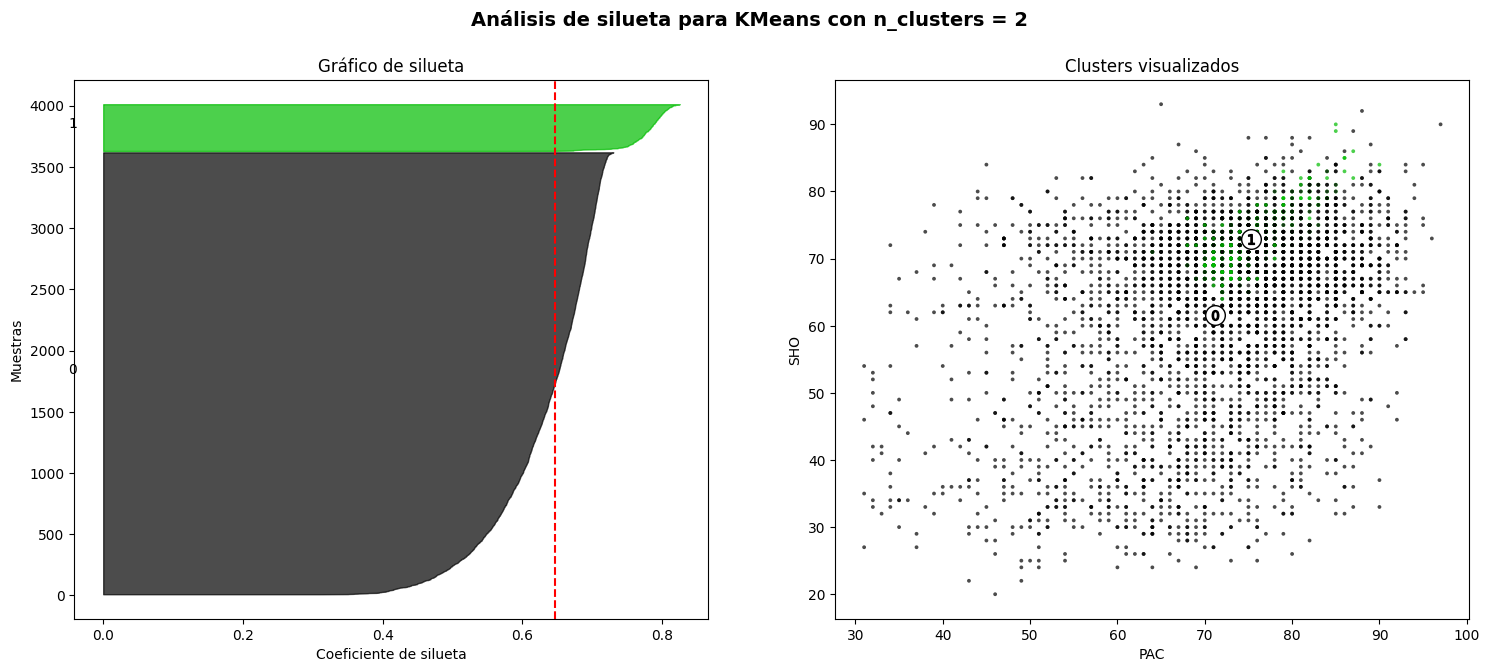

Para n_clusters = 3, el silhouette_score promedio es: 0.362


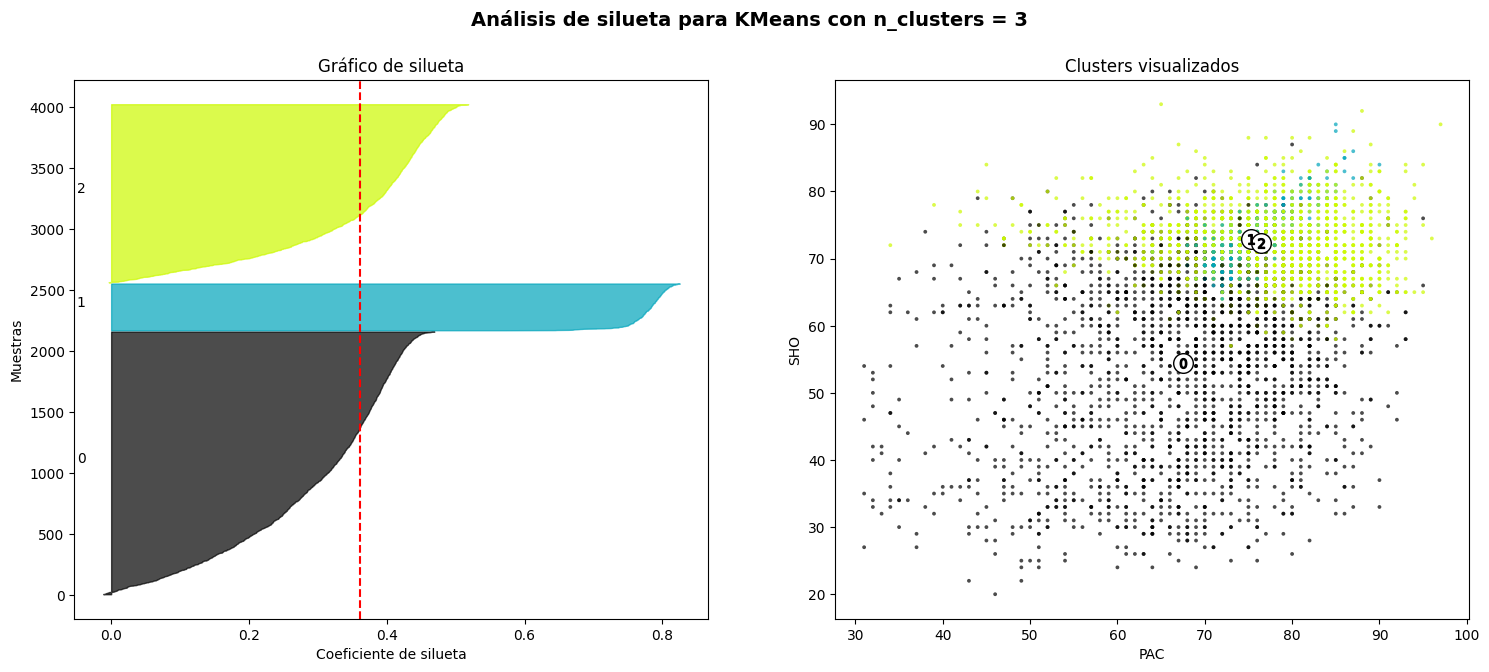

Para n_clusters = 4, el silhouette_score promedio es: 0.350


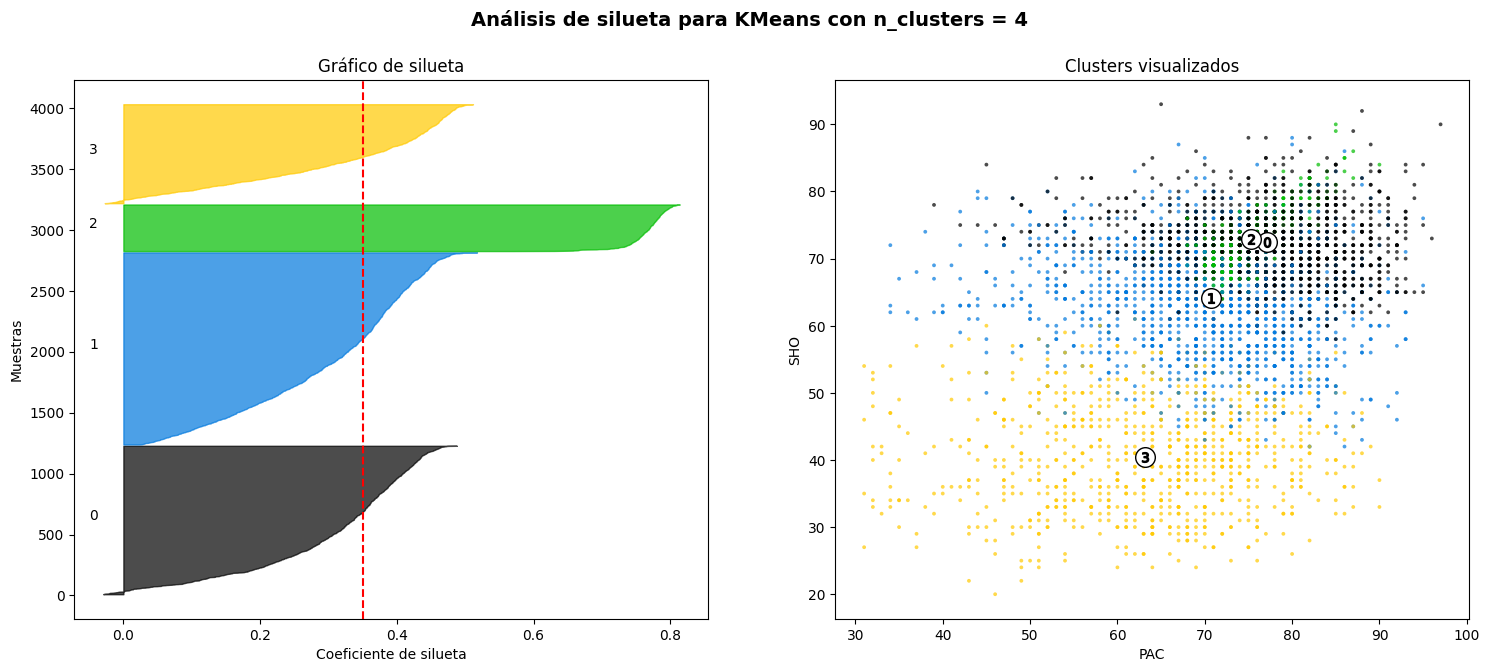

Para n_clusters = 5, el silhouette_score promedio es: 0.306


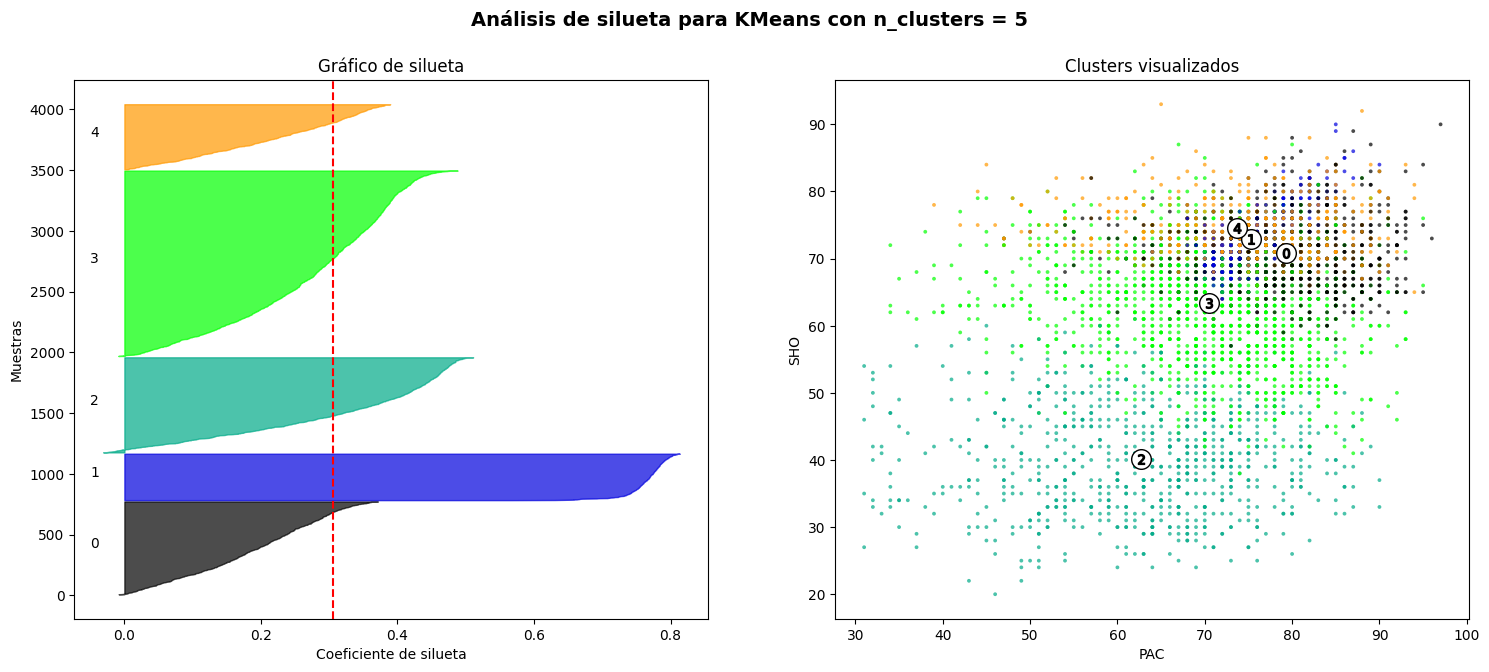

Para n_clusters = 6, el silhouette_score promedio es: 0.253


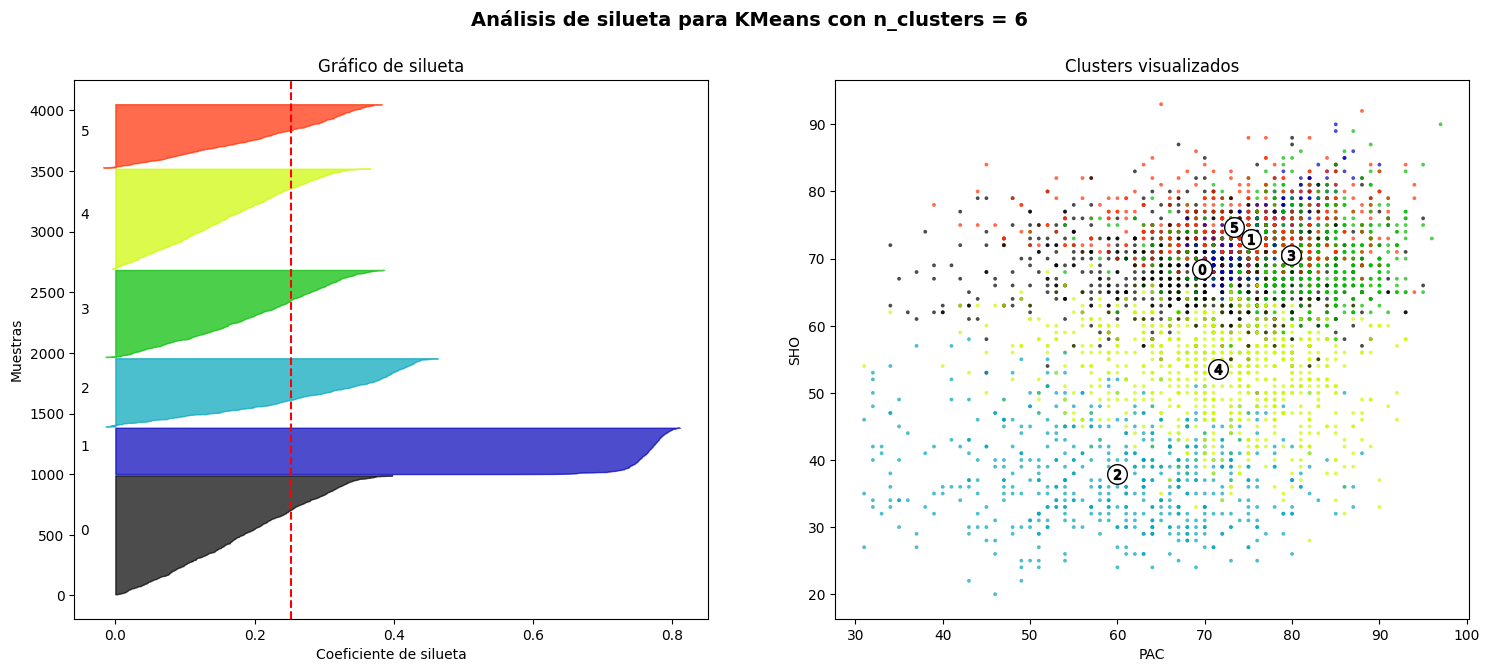

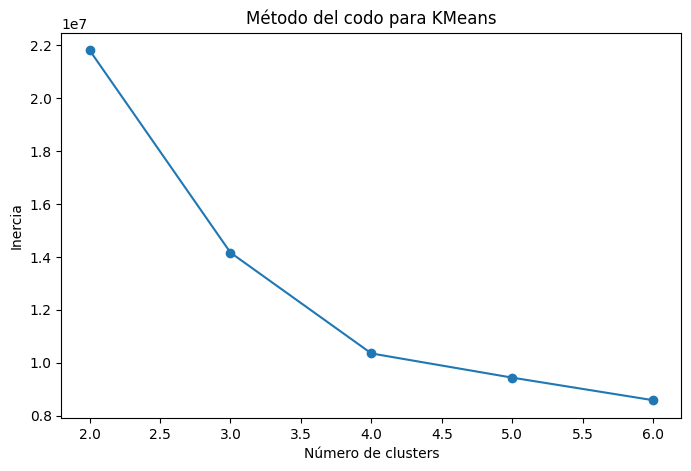

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt

X = pd.concat([df_encoded[skills], df_encoded[mlb.classes_]], axis=1)

range_n_clusters = [2, 3, 4, 5, 6]
sse = {}

skill_1 = skills[0]
skill_2 = skills[1]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)
    cluster_labels = clusterer.fit_predict(X)
    sse[n_clusters] = clusterer.inertia_

    # Calcular silueta promedio
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"Para n_clusters = {n_clusters}, el silhouette_score promedio es: {silhouette_avg:.3f}")

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Gráfico de silueta")
    ax1.set_xlabel("Coeficiente de silueta")
    ax1.set_ylabel("Muestras")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    # Gráfico de clusters en dos dimensiones
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[skill_1], X[skill_2], marker='.', s=30, lw=0,
                alpha=0.7, c=colors, edgecolor='k')

    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')
    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker=f'${i}$', alpha=1, s=50, edgecolor='k')

    ax2.set_title("Clusters visualizados")
    ax2.set_xlabel(skill_1)
    ax2.set_ylabel(skill_2)

    plt.suptitle((f"Análisis de silueta para KMeans con n_clusters = {n_clusters}"),
                 fontsize=14, fontweight='bold')
    plt.show()

# Método del codo
plt.figure(figsize=(8,5))
plt.plot(list(sse.keys()), list(sse.values()), 'o-')
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo para KMeans")
plt.show()

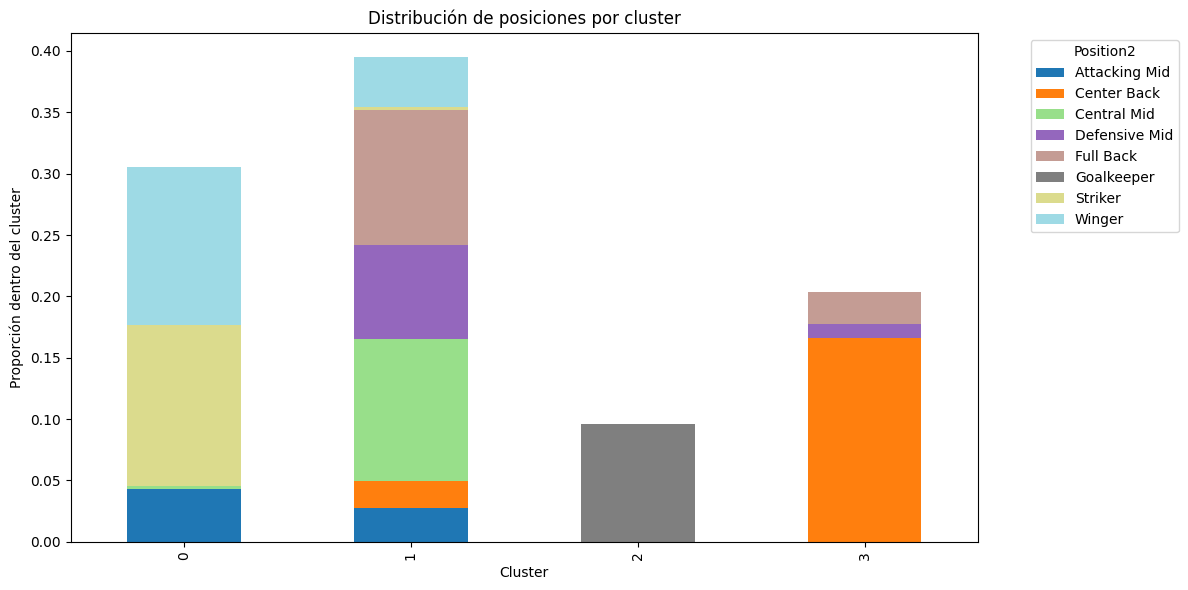

In [54]:
kmeans_final = KMeans(n_clusters=4, random_state=10, n_init=10)
df_n["Cluster"] = kmeans_final.fit_predict(X)

ct = pd.crosstab(df_n["Cluster"], df_n["Position2"], normalize=True)

# Visualización
ct.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Distribución de posiciones por cluster")
plt.ylabel("Proporción dentro del cluster")
plt.xlabel("Cluster")
plt.legend(title="Position2", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()